# House Prices Regression - Modelling

## 1. Modelling Overview

This notebook focuses on preparing the data and training Machine Learning models to predict house sale prices.

The main steps include data cleaning, feature engineering, preprocessing, model training, model comparison, hyperparameter tuning and final evaluation.

The train-test split will be recreated using the same random state used in the EDA notebook to ensure consistency.

The test set will remain untouched until the final evaluation stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import importlib
import joblib
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
sys.path.append('../src')

In [2]:
from feature_engineering import create_features
from feature_engineering import evaluate_model_cv

## 2. Load Dataset

The original dataset is loaded from the raw data folder.

No transformations are applied at this stage.

In [3]:
df = pd.read_csv("../input/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.shape

(2930, 82)

## 3. Train-Test Split

The dataset is split into training and test sets before any preprocessing step.

The training set will be used for data cleaning, feature engineering, preprocessing and model training.

The test set will only be used at the end to evaluate the final selected model.

In [5]:
target = 'SalePrice'
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2344, 81)
X_test shape: (586, 81)
y_train shape: (2344,)
y_test shape: (586,)


In [6]:
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
y_train_clean = y_train.copy()
y_test_clean = y_test.copy()

print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_test_clean shape: {X_test_clean.shape}")

X_train_clean shape: (2344, 81)
X_test_clean shape: (586, 81)


## 4. Initial Modelling Checklist

Before training models, the following steps must be performed:

1. Remove unnecessary identifier columns
2. Handle potential outliers in the training data
3. Treat missing values
4. Create engineered features
5. Encode categorical variables
6. Scale numerical variables when needed
7. Train a baseline model
8. Compare multiple regression models
9. Tune the best model
10. Evaluate the final model on the test set

## 5. Data Cleaning

In this section, we start cleaning the dataset before model training.

The first step is to remove identifier columns that do not provide predictive information for the model.

Columns such as `Order` and `PID` are useful for identifying records, but they should not be used as input features for machine learning models.

In [7]:
identifier_columns = ['Order', 'PID']
[col for col in identifier_columns if col in X_train_clean.columns]

['Order', 'PID']

In [8]:
X_train_clean = X_train_clean.drop(columns=identifier_columns)
X_test_clean = X_test_clean.drop(columns=identifier_columns)

print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_test_clean shape: {X_test_clean.shape}")

X_train_clean shape: (2344, 79)
X_test_clean shape: (586, 79)


In [9]:
[col for col in identifier_columns if col in X_train_clean.columns]

[]

### 5.1 Outlier Treatment

Based on the EDA, some observations with extremely high `Gr Liv Area` may behave as outliers.

These observations can strongly influence regression models, especially linear models.

Outliers will be removed only from the training set.  
The test set will remain untouched to represent unseen real-world data.

In [10]:
train_clean_check = X_train_clean.copy()
train_clean_check["SalePrice"] = y_train_clean
gr_liv_area_outliers = train_clean_check[train_clean_check["Gr Liv Area"] > 4000]
gr_liv_area_outliers[
    [
        "Gr Liv Area",
        "SalePrice",
        "Overall Qual",
        "Neighborhood"
    ]
].sort_values(by="Gr Liv Area", ascending=False)

,Gr Liv Area,SalePrice,Overall Qual,Neighborhood
1498,5642,160000,10,Edwards
2180,5095,183850,10,Edwards
1760,4476,745000,10,NoRidge
1767,4316,755000,10,NoRidge


In [11]:
outlier_indexes = X_train_clean[X_train_clean["Gr Liv Area"] > 4000].index
print(f"Number of outliers to remove: {len(outlier_indexes)}")

X_train_clean = X_train_clean.drop(index=outlier_indexes)
y_train_clean = y_train_clean.drop(index=outlier_indexes)

print(f"X_train_clean shape after outlier removal: {X_train_clean.shape}")
print(f"y_train_clean shape after outlier removal: {y_train_clean.shape}")

Number of outliers to remove: 4
X_train_clean shape after outlier removal: (2340, 79)
y_train_clean shape after outlier removal: (2340,)


In [12]:
print(f"X_test_clean shape: {X_test_clean.shape}")
print(f"y_test_clean shape: {y_test_clean.shape}")

X_test_clean shape: (586, 79)
y_test_clean shape: (586,)


### Data Cleaning Notes

The identifier columns `Order` and `PID` were removed because they do not represent meaningful property characteristics for price prediction.

Extreme observations with `Gr Liv Area` greater than 4000 were removed from the training set only. These observations were identified during the EDA as potential outliers that could strongly affect regression models.

The test set was not modified during outlier removal. This is important because the test set must remain untouched until the final evaluation stage.

## 6. Feature Engineering

In this section, new features are created based on the insights from the exploratory data analysis.

The goal is to create variables that better represent property size, age, renovation status, bathroom capacity and the presence of important property characteristics.

The same transformations will be applied to both training and test sets to keep them consistent.

In [13]:
X_train_fe = create_features(X_train_clean)
X_test_fe = create_features(X_test_clean)

print(f"X_train_fe shape: {X_train_fe.shape}")
print(f"X_test_fe shape: {X_test_fe.shape}")

X_train_fe shape: (2340, 87)
X_test_fe shape: (586, 87)


In [14]:
engineered_features = ["TotalSF","HouseAge","RemodAge","TotalBath","HasGarage","HasBasement","HasFireplace","HasPool"]
X_train_fe[engineered_features].head()

,TotalSF,HouseAge,RemodAge,TotalBath,HasGarage,HasBasement,HasFireplace,HasPool
381,2460.0,33,33,2.0,1,1,1,0
834,3139.0,42,42,3.0,1,1,0,0
1898,1224.0,45,45,2.0,1,0,0,0
678,1040.0,60,59,2.0,1,0,0,0
700,2301.0,89,59,2.0,0,1,0,0


In [15]:
same_columns = X_train_fe.columns.equals(X_test_fe.columns)

print(f"Train and test have the same columns: {same_columns}")

Train and test have the same columns: True


In [16]:
train_fe_analysis = X_train_fe.copy()
train_fe_analysis["SalePrice"] = y_train_clean
engineered_corr = train_fe_analysis[engineered_features + ["SalePrice"]].corr()["SalePrice"]
engineered_corr = engineered_corr.sort_values(ascending=False)
engineered_corr

SalePrice       1.000000
TotalSF         0.813423
TotalBath       0.642083
HasFireplace    0.477883
HasGarage       0.224693
HasBasement     0.162707
HasPool         0.068039
RemodAge       -0.529361
HouseAge       -0.554716
Name: SalePrice, dtype: float64

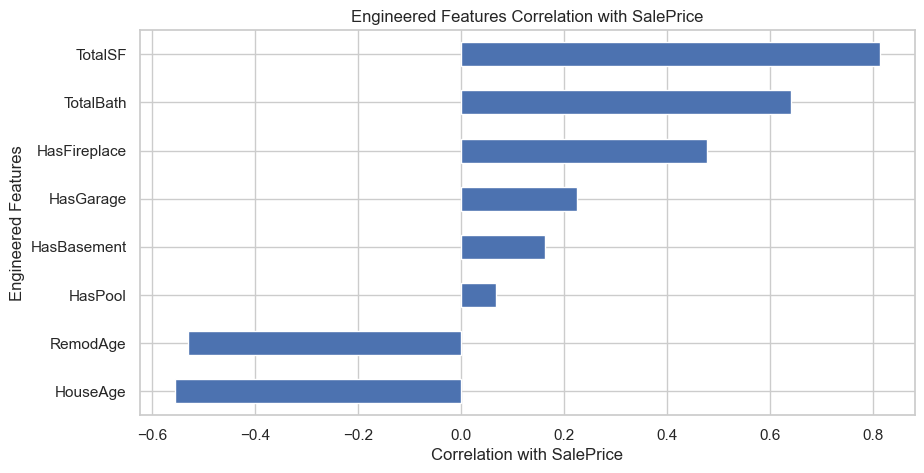

In [17]:
engineered_corr_without_target = engineered_corr.drop("SalePrice")
plt.figure(figsize=(10, 5))
engineered_corr_without_target.sort_values().plot(kind="barh")
plt.title("Engineered Features Correlation with SalePrice")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Engineered Features")
plt.show()

In [18]:
negative_house_age = (X_train_fe["HouseAge"] < 0).sum()
negative_remod_age = (X_train_fe["RemodAge"] < 0).sum()

print(f"Negative HouseAge values: {negative_house_age}")
print(f"Negative RemodAge values: {negative_remod_age}")

Negative HouseAge values: 0
Negative RemodAge values: 0


### Feature Engineering Notes

New features were created to better represent important property characteristics.

`TotalSF` combines basement area, first floor area and second floor area, representing the overall size of the property.

`HouseAge` and `RemodAge` capture the age of the house and the time since the last remodeling.

`TotalBath` summarizes full and half bathrooms, including basement bathrooms.

Binary features such as `HasGarage`, `HasBasement`, `HasFireplace` and `HasPool` indicate the presence or absence of important house characteristics.

These features will be included in the preprocessing and modeling pipeline.

## 7. Missing Value Treatment

In this section, missing values are handled according to their meaning.

Some missing values represent the absence of a property characteristic, such as no garage, no basement, no fireplace or no pool. These values will be filled with `"None"` for categorical variables or `0` for numerical variables.

Other missing values represent unknown information and will be imputed using statistical strategies such as the median for numerical features or the most frequent value for categorical features.

The imputation strategy will be included in a preprocessing pipeline to avoid data leakage.

In [19]:
missing_train = X_train_fe.isna().sum()
missing_train = missing_train[missing_train > 0]
missing_train = missing_train.sort_values(ascending=False)
missing_train

Pool QC           2330
Misc Feature      2247
Alley             2178
Fence             1871
Mas Vnr Type      1425
Fireplace Qu      1144
Lot Frontage       393
Garage Yr Blt      122
Garage Cond        122
Garage Qual        122
Garage Finish      122
Garage Type        120
Bsmt Exposure       63
BsmtFin Type 2      62
Bsmt Qual           61
BsmtFin Type 1      61
Bsmt Cond           61
Mas Vnr Area        19
BsmtFin SF 1         1
Bsmt Half Bath       1
Garage Cars          1
Garage Area          1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Bsmt Full Bath       1
dtype: int64

In [20]:
categorical_features = X_train_fe.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

Categorical features: 43
Numerical features: 40


In [21]:
categorical_none_features = ["Pool QC","Misc Feature","Alley","Fence",
    "Fireplace Qu","Garage Type","Garage Finish","Garage Qual",
    "Garage Cond","Bsmt Qual","Bsmt Cond","Bsmt Exposure",
    "BsmtFin Type 1","BsmtFin Type 2","Mas Vnr Type"
]

categorical_none_features = [col for col in categorical_none_features if col in X_train_fe.columns]
categorical_mode_features = [col for col in categorical_features if col not in categorical_none_features]

print(f"Categorical None features: {len(categorical_none_features)}")
print(f"Categorical mode features: {len(categorical_mode_features)}")

Categorical None features: 15
Categorical mode features: 28


In [22]:
numeric_zero_features = ["Mas Vnr Area","Garage Yr Blt","Garage Cars",
    "Garage Area","BsmtFin SF 1","BsmtFin SF 2","Bsmt Unf SF",
    "Total Bsmt SF","Bsmt Full Bath","Bsmt Half Bath"
]

numeric_zero_features = [col for col in numeric_zero_features if col in X_train_fe.columns]
numeric_median_features = [col for col in numerical_features if col not in numeric_zero_features]

print(f"Numeric zero features: {len(numeric_zero_features)}")
print(f"Numeric median features: {len(numeric_median_features)}")

Numeric zero features: 10
Numeric median features: 30


In [23]:
binary_features = ["HasGarage","HasBasement","HasFireplace","HasPool"]
print(f"Binary features: {len(binary_features)}")

Binary features: 4


In [24]:
all_selected_features = (
    categorical_none_features +
    categorical_mode_features +
    numeric_zero_features +
    numeric_median_features +
    binary_features
)

print(f"Total columns in X_train_fe: {X_train_fe.shape[1]}")
print(f"Total selected features: {len(all_selected_features)}")

missing_from_groups = [col for col in X_train_fe.columns if col not in all_selected_features]
missing_from_groups

Total columns in X_train_fe: 87
Total selected features: 87


[]

In [25]:
numeric_zero_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

numeric_median_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_none_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

categorical_mode_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num_zero", numeric_zero_transformer, numeric_zero_features),
        ("num_median", numeric_median_transformer, numeric_median_features),
        ("cat_none", categorical_none_transformer, categorical_none_features),
        ("cat_mode", categorical_mode_transformer, categorical_mode_features)
    ],

    remainder="drop"
)

In [27]:
X_train_processed = preprocessor.fit_transform(X_train_fe)
X_test_processed = preprocessor.transform(X_test_fe)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (2340, 317)
X_test_processed shape: (586, 317)


In [28]:
train_missing_after_processing = np.isnan(X_train_processed).sum()
test_missing_after_processing = np.isnan(X_test_processed).sum()

print(f"Missing values in processed training data: {train_missing_after_processing}")
print(f"Missing values in processed test data: {test_missing_after_processing}")

Missing values in processed training data: 0
Missing values in processed test data: 0


### Missing Value Treatment Notes

Missing values were treated according to their meaning.

Categorical variables where missing values indicate absence of a property characteristic were filled with `"None"`.

Numerical variables related to absent structures, such as garage, basement or masonry veneer area, were filled with `0`.

Other numerical variables were imputed using the median, and other categorical variables were imputed using the most frequent category.

All preprocessing steps were included in a `ColumnTransformer`, which ensures that imputation values are learned only from the training data and then applied to the test data.

## 8. Baseline Model

In this section, baseline models are created to establish initial performance references.

The first baseline is a `DummyRegressor`, which predicts the median sale price for every house. This model does not learn any relationship from the features and serves as a naive benchmark.

The second baseline is a `Ridge Regression` model. Ridge is a regularized linear model that helps reduce the impact of multicollinearity and large coefficients.

A standard `LinearRegression` model will not be used as the main linear baseline because the preprocessing step creates many one-hot encoded features. This can increase dimensionality and introduce multicollinearity, making an unregularized linear model less stable.

Therefore, Ridge Regression is used as a stronger and more reliable linear baseline.

In [29]:
dummy_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="median"))
])

In [30]:
dummy_results = evaluate_model_cv(
    dummy_pipeline,
    X_train_fe,
    y_train_clean,
    cv=5
)

dummy_results

{'MAE': 53692.479059829064,
 'RMSE': 77452.25524016068,
 'R2': -0.059035919404605154}

In [31]:
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [32]:
ridge_results = evaluate_model_cv(
    ridge_pipeline,
    X_train_fe,
    y_train_clean,
    cv=5
)

ridge_results

{'MAE': 15042.517246454172,
 'RMSE': 21791.57464340359,
 'R2': 0.9157727540455867}

In [33]:
baseline_results = pd.DataFrame({
    "Model": ["Dummy Regressor", "Ridge Regression"],
    "MAE": [dummy_results["MAE"], ridge_results["MAE"]],
    "RMSE": [dummy_results["RMSE"], ridge_results["RMSE"]],
    "R2": [dummy_results["R2"], ridge_results["R2"]]
})

baseline_results = baseline_results.sort_values(by="RMSE", ascending=True)
baseline_results

,Model,MAE,RMSE,R2
1,Ridge Regression,15042.517246,21791.574643,0.915773
0,Dummy Regressor,53692.479060,77452.255240,-0.059036


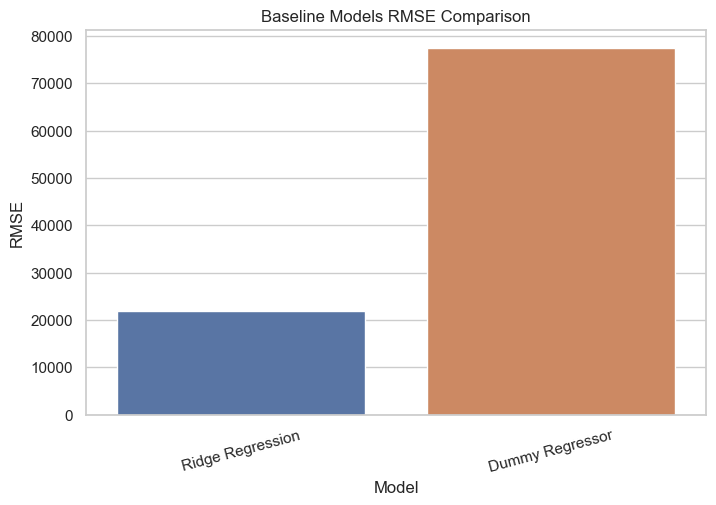

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=baseline_results,
    x="Model",
    y="RMSE"
)
plt.title("Baseline Models RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

### Baseline Model Notes

The `DummyRegressor` was used as a naive baseline. It predicts the median sale price for every property and does not learn from the input features.

The `LinearRegression` model was intentionally not used as the main linear baseline. After preprocessing, the dataset contains many one-hot encoded categorical variables, which increases dimensionality and may introduce multicollinearity. In this situation, an unregularized linear model can become less stable.

Instead, `Ridge Regression` was selected as the linear baseline because it applies L2 regularization. This helps control large coefficients and makes the model more robust when dealing with many correlated or encoded features.

If Ridge Regression performs significantly better than the Dummy Regressor, it indicates that the dataset contains useful predictive patterns for estimating house prices.

## 9. Model Comparison

In this section, multiple regression models are trained and evaluated using cross-validation.

All models use the same preprocessing pipeline to ensure a fair comparison.

The goal is to identify which models provide the best predictive performance before moving to hyperparameter tuning.

In [35]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),                                                           # Ridge Regression is a regularized linear model using L2 penalty
    #"Lasso Regression": Lasso(alpha=0.1, max_iter=200000, tol=1e-3, random_state=42),               # Lasso Regression is a regularized linear model using L1 penalty
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=200000, tol=1e-3, random_state=42),  # ElasticNet combines L1 and L2 regularization
    "Random Forest": RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1),             # Random Forest is an ensemble of decision trees
    "Extra Trees": ExtraTreesRegressor(n_estimators=300,random_state=42,n_jobs=-1),                 # Extra Trees is a more randomized tree-based ensemble
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)                                 # Gradient Boosting builds trees sequentially to reduce errors
}                        

In [36]:
model_results_list = []

for model_name, model in models.items():
    
    model_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("model", model)])
    results = evaluate_model_cv(model_pipeline,X_train_fe,y_train_clean,cv=5)
    model_results_list.append({
        "Model": model_name,
        "MAE": results["MAE"],
        "RMSE": results["RMSE"],
        "R2": results["R2"]
    })

model_comparison = pd.DataFrame(model_results_list)
model_comparison = model_comparison.sort_values(by="RMSE", ascending=True)
model_comparison

,Model,MAE,RMSE,R2
4,Gradient Boosting,14127.472256,21166.187673,0.920267
0,Ridge Regression,15042.517246,21791.574643,0.915773
1,ElasticNet,15015.950938,22055.762213,0.913863
3,Extra Trees,14714.442677,22606.434708,0.909709
2,Random Forest,15418.092949,23422.496281,0.902753


In [37]:
dummy_baseline_row = pd.DataFrame({
    "Model": ["Dummy Regressor"],
    "MAE": [dummy_results["MAE"]],
    "RMSE": [dummy_results["RMSE"]],
    "R2": [dummy_results["R2"]]
})

full_model_comparison = pd.concat(
    [model_comparison, dummy_baseline_row],
    ignore_index=True
)

full_model_comparison = full_model_comparison.sort_values(by="RMSE", ascending=True)
full_model_comparison

,Model,MAE,RMSE,R2
0,Gradient Boosting,14127.472256,21166.187673,0.920267
1,Ridge Regression,15042.517246,21791.574643,0.915773
2,ElasticNet,15015.950938,22055.762213,0.913863
3,Extra Trees,14714.442677,22606.434708,0.909709
4,Random Forest,15418.092949,23422.496281,0.902753
5,Dummy Regressor,53692.479060,77452.255240,-0.059036


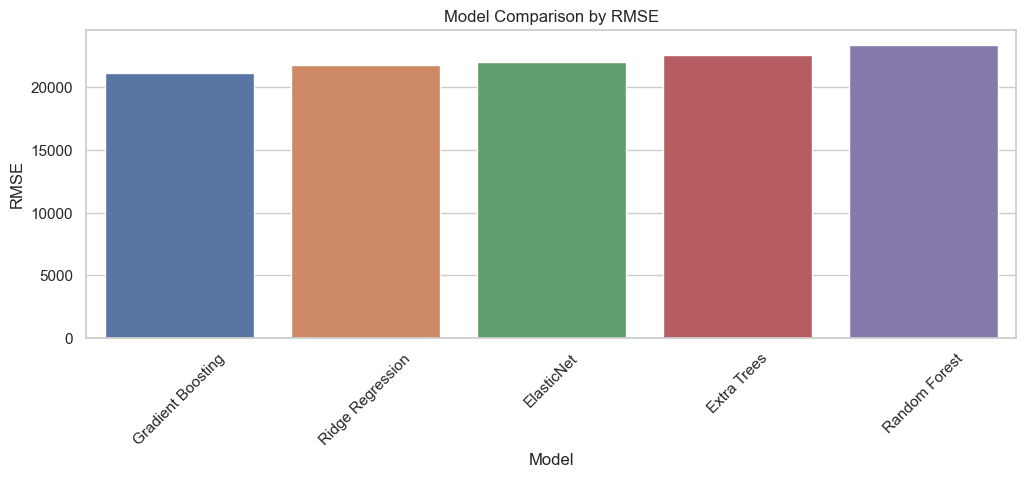

In [38]:
plt.figure(figsize=(12, 4))
sns.barplot(data=model_comparison,x="Model",y="RMSE")
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

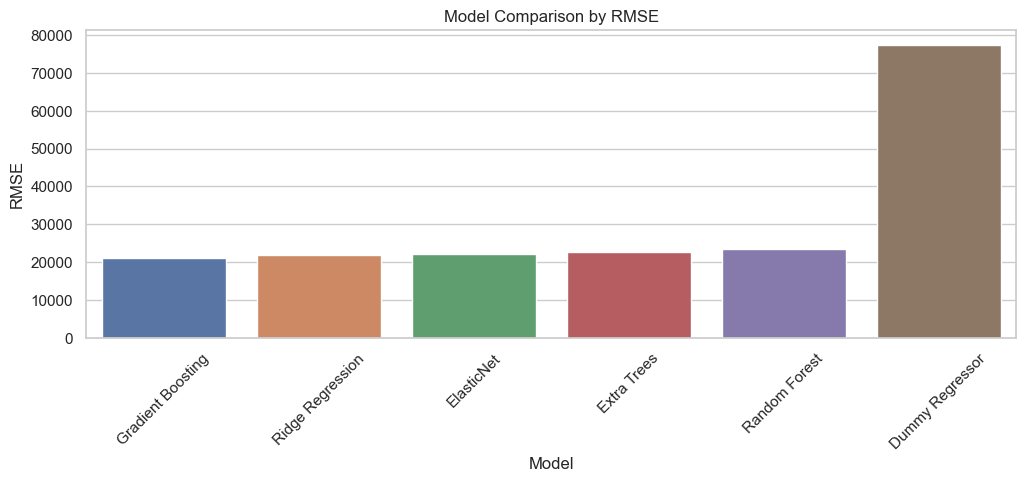

In [39]:
plt.figure(figsize=(12, 4))
sns.barplot(data=full_model_comparison,x="Model",y="RMSE")
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

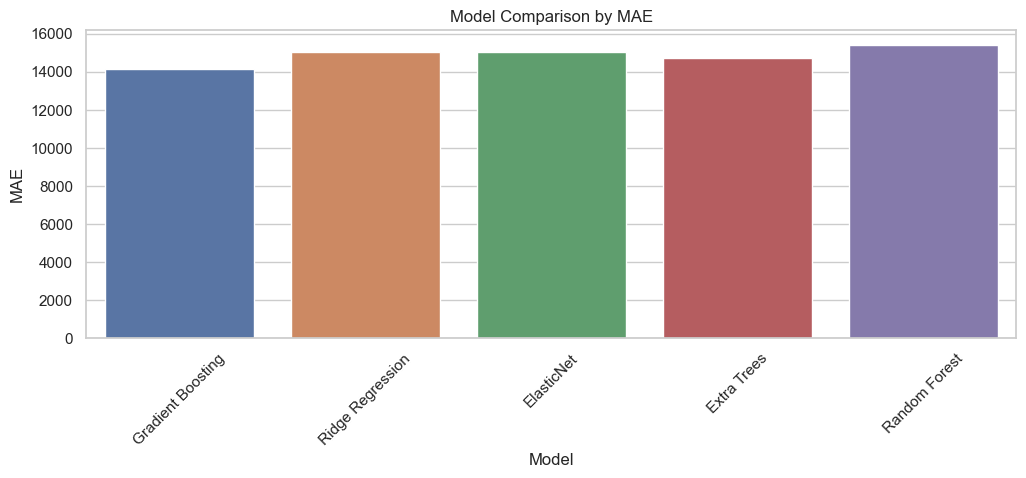

In [40]:
plt.figure(figsize=(12, 4))
sns.barplot(data=model_comparison,x="Model",y="MAE")
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

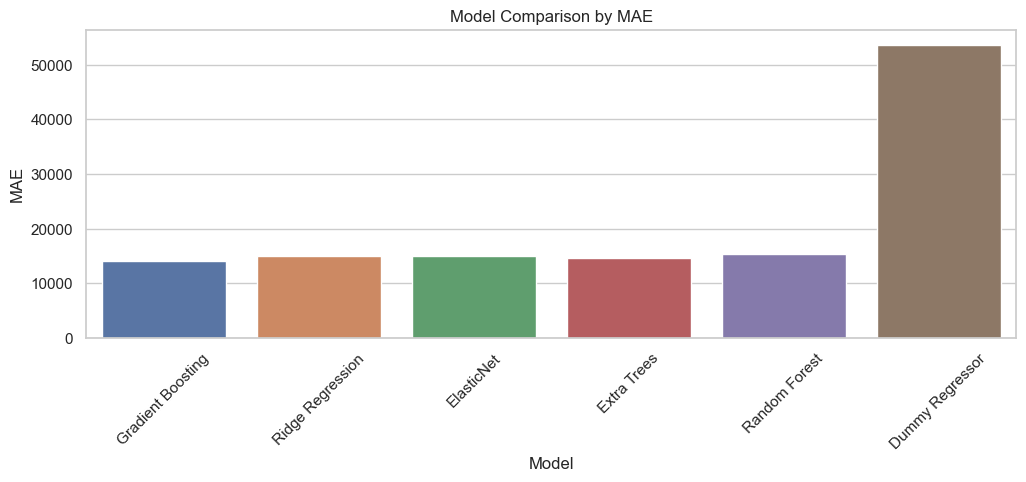

In [41]:
plt.figure(figsize=(12, 4))
sns.barplot(data=full_model_comparison,x="Model",y="MAE")
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

In [42]:
best_model_name = full_model_comparison.iloc[0]["Model"]
best_model_rmse = full_model_comparison.iloc[0]["RMSE"]
best_model_mae = full_model_comparison.iloc[0]["MAE"]
best_model_r2 = full_model_comparison.iloc[0]["R2"]

print(f"Best model: {best_model_name}")
print(f"Best RMSE: {best_model_rmse:,.2f}")
print(f"Best MAE: {best_model_mae:,.2f}")
print(f"Best R2: {best_model_r2:.4f}")

Best model: Gradient Boosting
Best RMSE: 21,166.19
Best MAE: 14,127.47
Best R2: 0.9203


### Model Comparison Notes

Multiple regression models were evaluated using the same preprocessing pipeline and 5-fold cross-validation.

The `DummyRegressor` was included as a naive baseline to verify whether the machine learning models were actually learning useful patterns from the data.

Regularized linear models such as Ridge, Lasso and ElasticNet provide interpretable baselines and help deal with high-dimensional data created by one-hot encoding.

Tree-based ensemble models such as Random Forest, Extra Trees and Gradient Boosting can capture non-linear relationships between house characteristics and sale prices.

The best-performing model based on cross-validation RMSE will be selected for hyperparameter tuning in the next section.

## 10. Hyperparameter Tuning

The best model from the model comparison step was `Gradient Boosting`.

In this section, hyperparameter tuning will be performed using cross-validation on the training data only.

The goal is to improve the model performance by testing different combinations of hyperparameters.

The test set will remain untouched and will only be used for the final evaluation.

In [43]:
gradient_boosting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [44]:
gb_param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 0.9, 1.0]
}

In [45]:
gb_random_search = RandomizedSearchCV(
    estimator=gradient_boosting_pipeline,
    param_distributions=gb_param_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [46]:
gb_random_search.fit(X_train_fe, y_train_clean)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num_zero',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(fill_value=0,
                                                                                                              strategy='constant')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Mas '
                                                                                'Vnr '
                                                                                'Area',
                                                                                'Garage '
                                                                                'Yr '
                                                                                'Blt',
                                                                                'Garage '
                                                                                'Cars',
                                                                                'Garage '
                                                                                'Area',
                                                                                'BsmtFin '
                                                                                'SF '
                                                                                '1',
                                                                                'BsmtFin '
                                                                                'SF '
                                                                                '2',
                                                                                'Bsmt '
                                                                                'Unf '
                                                                                'SF',
                                                                                'Total '
                                                                                'Bsmt '
                                                                                'SF',...
                                              GradientBoostingRegressor(random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [47]:
gb_random_search.best_params_

{'model__subsample': 0.9,
 'model__n_estimators': 500,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 4,
 'model__max_depth': 3,
 'model__learning_rate': 0.1}

In [48]:
best_gb_cv_rmse = -gb_random_search.best_score_

print(f"Best Gradient Boosting CV RMSE: {best_gb_cv_rmse:,.2f}")

Best Gradient Boosting CV RMSE: 20,242.32


In [49]:
best_gb_model = gb_random_search.best_estimator_
best_gb_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_zero',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Mas Vnr Area',
                                                   'Garage Yr Blt',
                                                   'Garage Cars', 'Garage Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   'Bsmt Full Bath',
                                                   'Bsmt Half Bath']),
                                                 ('num_median',
                                                  Pipeline(steps=[...
                                                   'Bldg Type', 'House Style',
                                                   'Roof Style', 'Roof Matl',
                                                   'Exterior 1st',
                                                   'Exterior 2nd', 'Exter Qual',
                                                   'Exter Cond', 'Foundation',
                                                   'Heating', 'Heating QC',
                                                   'Central Air', 'Electrical',
                                                   'Kitchen Qual', 'Functional',
                                                   'Paved Drive', 'Sale Type',
                                                   'Sale Condition'])])),
                ('model',
                 GradientBoostingRegressor(min_samples_leaf=4,
                                           min_samples_split=5,
                                           n_estimators=500, random_state=42,
                                           subsample=0.9))])

In [50]:
gb_before_tuning_rmse = 21166.19
gb_after_tuning_rmse = best_gb_cv_rmse
rmse_improvement = gb_before_tuning_rmse - gb_after_tuning_rmse
rmse_improvement_pct = (rmse_improvement / gb_before_tuning_rmse) * 100


print(f"Gradient Boosting RMSE before tuning: {gb_before_tuning_rmse:,.2f}")
print(f"Gradient Boosting RMSE after tuning: {gb_after_tuning_rmse:,.2f}")
print(f"RMSE improvement: {rmse_improvement:,.2f}")
print(f"RMSE improvement percentage: {rmse_improvement_pct:.2f}%")

Gradient Boosting RMSE before tuning: 21,166.19
Gradient Boosting RMSE after tuning: 20,242.32
RMSE improvement: 923.87
RMSE improvement percentage: 4.36%


### Hyperparameter Tuning Notes

Hyperparameter tuning was performed on the `Gradient Boosting` model because it achieved the best cross-validation performance during the model comparison step.

The tuning process tested different combinations of `n_estimators`, `learning_rate`, `max_depth`, `min_samples_split`, `min_samples_leaf` and `subsample`.

The model was evaluated using 5-fold cross-validation and RMSE as the main metric.

The test set was not used during this step. It will only be used in the final evaluation stage after the best model has been selected.

## 11. Final Model Evaluation

In this section, the tuned Gradient Boosting model is evaluated on the test set.

The test set has remained untouched during the entire training, comparison and tuning process.

This final evaluation provides a realistic estimate of how the model may perform on unseen data.

In [51]:
y_test_pred = best_gb_model.predict(X_test_fe)
y_test_pred[:10]

array([178254.17089616, 104853.5764185 , 188799.46057459, 126051.10293323,
       121833.41786265, 173860.51219419, 172916.28187443, 149077.52559867,
        94030.15076104, 392380.83270682])

In [52]:
final_mae = mean_absolute_error(y_test_clean, y_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test_clean, y_test_pred))
final_r2 = r2_score(y_test_clean, y_test_pred)

print(f"Final Test MAE: ${final_mae:,.2f}")
print(f"Final Test RMSE: ${final_rmse:,.2f}")
print(f"Final Test R2: {final_r2:.4f}")

Final Test MAE: $13,712.51
Final Test RMSE: $26,098.88
Final Test R2: 0.9150


In [53]:
final_performance_comparison = pd.DataFrame({
    "Evaluation Step": ["Cross-Validation", "Final Test Set"],
    "RMSE": [best_gb_cv_rmse, final_rmse]
})

final_performance_comparison

,Evaluation Step,RMSE
0,Cross-Validation,20242.316679
1,Final Test Set,26098.880058


In [54]:
prediction_results = pd.DataFrame({
    "Actual SalePrice": y_test_clean,
    "Predicted SalePrice": y_test_pred
})

prediction_results["Error"] = prediction_results["Actual SalePrice"] - prediction_results["Predicted SalePrice"]
prediction_results["Absolute Error"] = prediction_results["Error"].abs()
prediction_results.head()

,Actual SalePrice,Predicted SalePrice,Error,Absolute Error
1357,161000,178254.170896,-17254.170896,17254.170896
2367,116000,104853.576419,11146.423581,11146.423581
2822,196500,188799.460575,7700.539425,7700.539425
2126,123600,126051.102933,-2451.102933,2451.102933
1544,126000,121833.417863,4166.582137,4166.582137


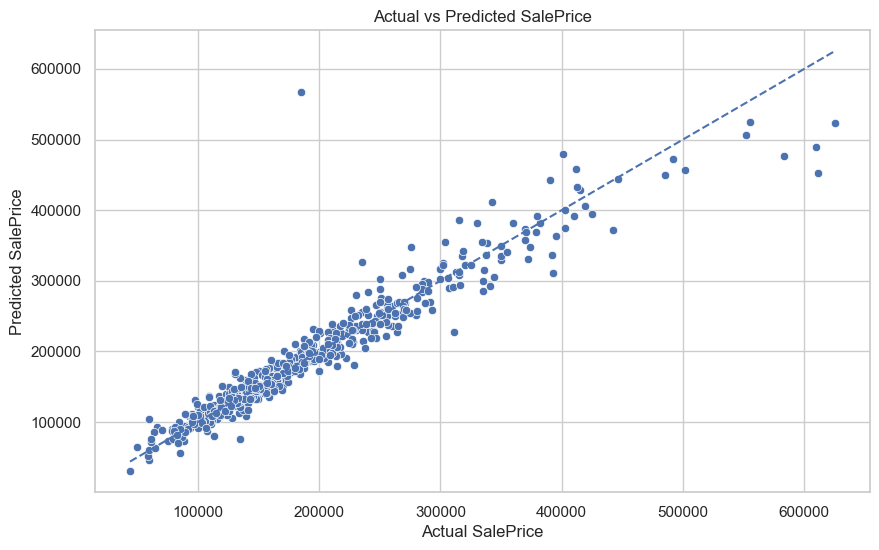

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=prediction_results["Actual SalePrice"],y=prediction_results["Predicted SalePrice"])
plt.plot(
    [prediction_results["Actual SalePrice"].min(), prediction_results["Actual SalePrice"].max()],
    [prediction_results["Actual SalePrice"].min(), prediction_results["Actual SalePrice"].max()],
    linestyle="--"
)
plt.title("Actual vs Predicted SalePrice")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()

c:\Users\davio\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


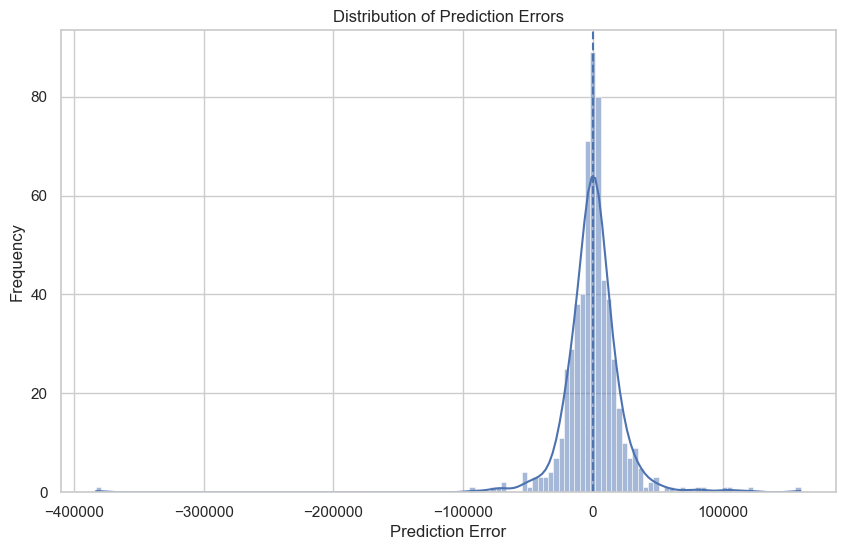

In [56]:
plt.figure(figsize=(10, 6))
sns.histplot(prediction_results["Error"], kde=True)
plt.axvline(x=0, linestyle="--")
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

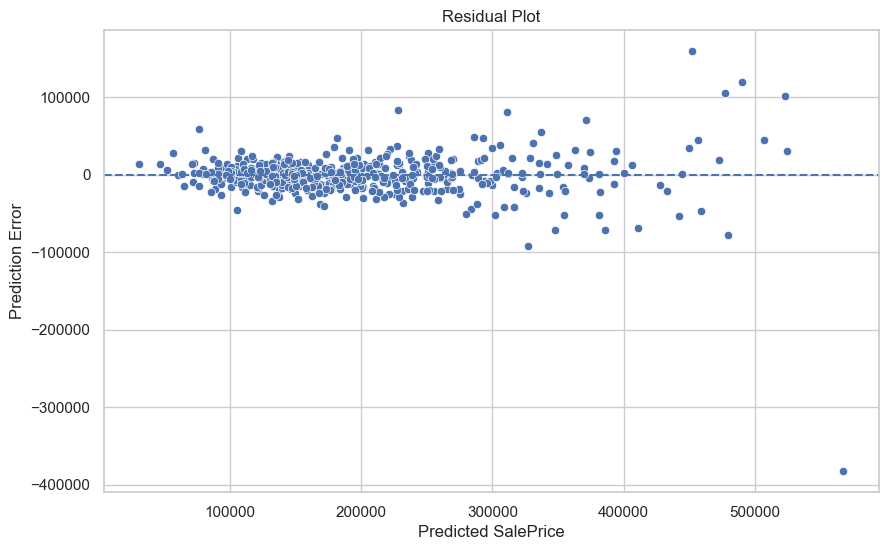

In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=prediction_results["Predicted SalePrice"],y=prediction_results["Error"])
plt.axhline(y=0, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Prediction Error")
plt.show()

In [58]:
prediction_results.sort_values(by="Absolute Error", ascending=False).head(10)

,Actual SalePrice,Predicted SalePrice,Error,Absolute Error
2181,184750,567623.138641,-382873.138641,382873.138641
44,611657,451909.575119,159747.424881,159747.424881
432,610000,490021.156711,119978.843289,119978.843289
433,582933,477022.830313,105910.169687,105910.169687
2445,625000,523386.507335,101613.492665,101613.492665
2246,235000,326988.796989,-91988.796989,91988.796989
1538,311500,227654.828922,83845.171078,83845.171078
1559,392500,311036.460044,81463.539956,81463.539956
2335,401179,479393.981441,-78214.981441,78214.981441
2103,276000,347511.339746,-71511.339746,71511.339746


### Final Model Evaluation Notes

The tuned Gradient Boosting model was evaluated on the test set, which was not used during training, model comparison or hyperparameter tuning.

The final MAE represents the average absolute prediction error in dollars.  
The final RMSE gives more weight to larger errors.  
The final R2 score indicates how much of the variation in house prices is explained by the model.

The actual vs predicted plot helps visualize how close the predictions are to the real sale prices.

The residual analysis helps identify whether the model errors are randomly distributed or whether there are systematic patterns that may require further investigation.

## 12. Model Interpretation

In this section, the final tuned Gradient Boosting model is interpreted using feature importance.

Feature importance helps identify which variables contributed the most to the model predictions.

This step is important because the goal of the project is not only to predict house prices, but also to understand which property characteristics are most relevant for price estimation.

In [59]:
fitted_preprocessor = best_gb_model.named_steps["preprocessor"]
fitted_model = best_gb_model.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

print(f"Number of processed features: {len(feature_names)}")

Number of processed features: 317


In [60]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": fitted_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance.head(20)

,Feature,Importance
13,num_median__Overall Qual,0.382137
36,num_median__TotalSF,0.335938
39,num_median__TotalBath,0.039566
37,num_median__HouseAge,0.027723
2,num_zero__Garage Cars,0.021981
12,num_median__Lot Area,0.017794
86,cat_none__Bsmt Qual_Ex,0.015564
286,cat_mode__Kitchen Qual_Ex,0.012328
4,num_zero__BsmtFin SF 1,0.011462
20,num_median__Gr Liv Area,0.010140


In [61]:
feature_importance_clean = feature_importance.copy()
feature_importance_clean["Feature"] = (
    feature_importance_clean["Feature"]
    .str.replace("num_zero__", "", regex=False)
    .str.replace("num_median__", "", regex=False)
    .str.replace("cat_none__", "", regex=False)
    .str.replace("cat_mode__", "", regex=False)
)

feature_importance_clean.head(20)

,Feature,Importance
13,Overall Qual,0.382137
36,TotalSF,0.335938
39,TotalBath,0.039566
37,HouseAge,0.027723
2,Garage Cars,0.021981
12,Lot Area,0.017794
86,Bsmt Qual_Ex,0.015564
286,Kitchen Qual_Ex,0.012328
4,BsmtFin SF 1,0.011462
20,Gr Liv Area,0.010140


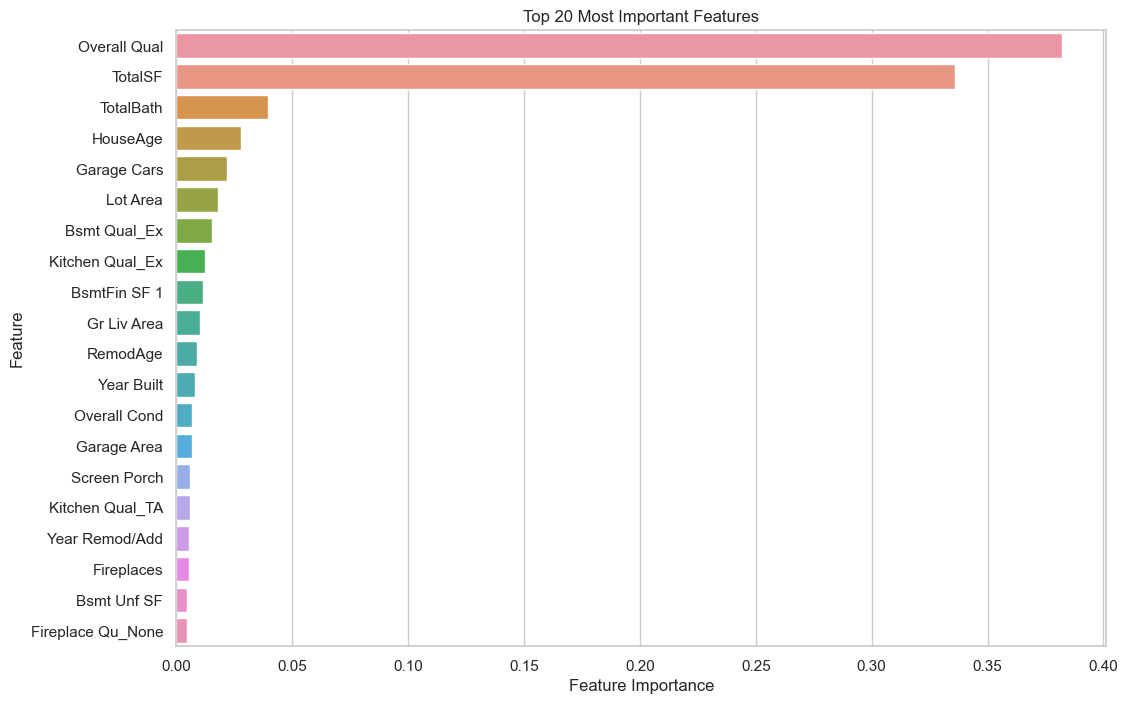

In [62]:
top_20_features = feature_importance_clean.head(20)
plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_features,x="Importance",y="Feature")
plt.title("Top 20 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

In [63]:
feature_importance_clean["Cumulative Importance"] = feature_importance_clean["Importance"].cumsum()
feature_importance_clean.head(20)

,Feature,Importance,Cumulative Importance
13,Overall Qual,0.382137,0.382137
36,TotalSF,0.335938,0.718075
39,TotalBath,0.039566,0.757640
37,HouseAge,0.027723,0.785363
2,Garage Cars,0.021981,0.807344
12,Lot Area,0.017794,0.825138
86,Bsmt Qual_Ex,0.015564,0.840702
286,Kitchen Qual_Ex,0.012328,0.853030
4,BsmtFin SF 1,0.011462,0.864492
20,Gr Liv Area,0.010140,0.874632


### Model Interpretation Notes

The feature importance analysis shows that the final Gradient Boosting model relies mostly on `Overall Qual` and `TotalSF`.

This result is consistent with the exploratory data analysis. Houses with higher overall quality and larger total square footage tend to have higher sale prices.

`TotalBath`, `HouseAge`, `Garage Cars`, `Lot Area`, `Bsmt Qual_Ex`, `Kitchen Qual_Ex`, `Gr Liv Area` and `RemodAge` also appear among the most important predictors.

These features represent important real estate price drivers, such as property size, construction quality, number of bathrooms, house age, garage capacity, lot size, basement quality, kitchen quality and renovation status.

The model is not only achieving strong predictive performance, but also learning patterns that make business sense in the real estate context.

In [64]:
artifacts_path = "../artifacts"

In [65]:
model_path = os.path.join(artifacts_path, "final_gradient_boosting_model.pkl")
joblib.dump(best_gb_model, model_path)

print(f"Final model saved at: {model_path}")

Final model saved at: ../artifacts\final_gradient_boosting_model.pkl


In [66]:
final_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [final_mae, final_rmse, final_r2]
})

metrics_path = os.path.join(artifacts_path, "final_model_metrics.csv")
final_metrics.to_csv(metrics_path, index=False)
final_metrics

,Metric,Value
0,MAE,13712.509222
1,RMSE,26098.880058
2,R2,0.915042


In [67]:
predictions_path = os.path.join(artifacts_path, "test_predictions.csv")
prediction_results.to_csv(predictions_path, index=False)

print(f"Test predictions saved at: {predictions_path}")

Test predictions saved at: ../artifacts\test_predictions.csv


In [68]:
loaded_model = joblib.load(model_path)
loaded_model_predictions = loaded_model.predict(X_test_fe)
predictions_match = np.allclose(y_test_pred, loaded_model_predictions)

print(f"Loaded model predictions match original predictions: {predictions_match}")

Loaded model predictions match original predictions: True


### Model Saving Notes

The final tuned Gradient Boosting pipeline was saved using `joblib`.

The saved object includes both the preprocessing steps and the trained model, which means it can receive raw input data with the same structure used during training and apply all required transformations automatically.

Final evaluation metrics and test set predictions were also saved as artifacts for documentation and future analysis.

## 13. Final Conclusions

This notebook completed the modeling stage of the House Prices Regression project.

The goal was to build a machine learning model capable of predicting residential house sale prices using the Ames Housing dataset.

The modeling pipeline included data cleaning, feature engineering, missing value treatment, preprocessing, model comparison, hyperparameter tuning, final evaluation and model saving.

### Pipeline Summary

The main steps performed in this notebook were:

1. The dataset was split into training and test sets using the same strategy defined in the EDA notebook.
2. Identifier columns such as `Order` and `PID` were removed.
3. Extreme outliers based on `Gr Liv Area` were removed only from the training set.
4. New features were created, including `TotalSF`, `HouseAge`, `RemodAge`, `TotalBath`, `HasGarage`, `HasBasement`, `HasFireplace` and `HasPool`.
5. Missing values were handled according to their meaning.
6. Categorical variables were encoded using One-Hot Encoding.
7. Numerical variables were scaled using StandardScaler.
8. Multiple regression models were compared using cross-validation.
9. The best model was tuned using RandomizedSearchCV.
10. The final tuned model was evaluated on the untouched test set.
11. The final model, metrics and predictions were saved as artifacts.

### Model Selection Summary

Several regression models were tested and compared using 5-fold cross-validation.

The models included:

- Dummy Regressor
- Ridge Regression
- Lasso Regression
- ElasticNet
- Random Forest
- Extra Trees
- Gradient Boosting

The `Dummy Regressor` was used as a naive baseline, predicting the median sale price for every property.

The best performing model before tuning was `Gradient Boosting`, with the following cross-validation performance:

- RMSE: approximately `$21,166`
- MAE: approximately `$14,127`
- R²: approximately `0.9203`

After hyperparameter tuning, the Gradient Boosting model improved its cross-validation RMSE to approximately `$20,242`, representing an improvement of about `4.36%`.

### Final Test Results

The final tuned Gradient Boosting model was evaluated on the test set, which had remained untouched during the entire modeling process.

The final test results were:

- MAE: `$13,712.51`
- RMSE: `$26,098.88`
- R²: `0.9150`

The MAE indicates that, on average, the model predictions are about `$13,713` away from the actual sale price.

The RMSE is higher than the MAE, which suggests that some larger prediction errors are present.

The R² score of `0.9150` indicates that the model explains approximately `91.5%` of the variation in house prices on unseen data.

### Model Interpretation Summary

The feature importance analysis showed that the most important predictors were mainly related to quality, size, age and property characteristics.

The most relevant features included:

- `Overall Qual`
- `TotalSF`
- `TotalBath`
- `HouseAge`
- `Garage Cars`
- `Lot Area`
- `Bsmt Qual_Ex`
- `Kitchen Qual_Ex`
- `Gr Liv Area`
- `RemodAge`

These results are consistent with the EDA findings.

The model learned that houses with higher overall quality, larger total area, more bathrooms, newer construction, larger garages and better kitchen or basement quality tend to have higher sale prices.

This makes sense from a real estate business perspective and increases confidence in the model behavior.

### Project Limitations

Although the final model achieved strong performance, some limitations should be considered.

The dataset represents houses sold in Ames, Iowa, and the model may not generalize directly to other cities or real estate markets.

Some external factors that can influence house prices are not present in the dataset, such as macroeconomic conditions, interest rates, local demand, school ratings, crime rates and market trends.

The model also showed some larger prediction errors, as indicated by the difference between MAE and RMSE. These errors may be related to unusual properties, high-value houses or observations with rare combinations of features.

Future improvements could include additional feature engineering, more advanced models, log transformation of the target variable and deeper error analysis.

### Final Conclusion

The final Gradient Boosting model achieved strong predictive performance and produced results that are consistent with real estate business logic.

The model was able to predict house sale prices with an average absolute error of approximately `$13,713` and explained about `91.5%` of the price variation in the test set.

The most important price drivers were overall quality, total property size, number of bathrooms, house age, garage capacity, lot area, basement quality and kitchen quality.

This project demonstrates a complete machine learning workflow, including business understanding, exploratory data analysis, preprocessing, feature engineering, model comparison, tuning, evaluation, interpretation and artifact saving.

The next step is to document the project in a professional `README.md` and later create a simple deployment application for interactive predictions.